<span style="color:blue;font-family:Times New Roman; font-size:27px; font-weight:bold;">
ANALYSING HISTORICAL STOCK/REVENUE DATA AND BUILDING A DASHBOARD
</span>

<span style="color:purple;font-family:Bahnschrift; font-size:24px; font-weight:bold;">
(1)Using yfinance to extract Stock Data
</span>

<span style="color:black;font-family:Arial; font-size:15px;">
The Ticker function and the ticker symbol of the stock are used to extract data to create a ticker object.The stock is Tesla and its ticker symbol is TSLA.Using the ticker object and the function history stock information is extracted and saved in a data frame named tesla_data. The period parameter is set to "max" to get information for the maximum amount of time.The index is reset using the reset_index (inplace=True) function on the tesla_data Dataframe and the first five rows of the tesla_data dataframe is displayed using the head function
</span>

In [3]:
import yfinance as yf
tesla=yf.Ticker("TSLA")
tesla_data=tesla.history (period="max")
tesla_data.reset_index(inplace=True)
print(tesla_data.head(5))

                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


<span style="color:blue;font-family:Arial;font-weight:bold; font-size:15px;">ANALYSIS :</span>
<span style="color:black;font-family:Arial; font-size:15px;">The displayed data shows the initial portion of Tesla’s historical stock data starting from June 2010.</span><br><span style="color:black;font-family:Arial; font-size:15px;">Open- The first price at which the stock was traded when the market opened that day.<br>Close- The last price at which the stock was traded when the market closed that day.<br>High- The highest price stock reached during that trading day.<br>Low- The lowest price stock reached during that trading day.<br>Volume- The number of shares traded during that day.<br>Dividends-Money that a company(i.e. Tesla) pays to its shareholders from its profits.<br>Stock splits- Occurs when a company increases the number of shares while reducing the price per share so that the total market value remains the same.<br>Averages of open, close, high, low are 1.5038666, 1.3998668, 1.6592, 1.275333 respectively. Since the average opening price is slightly higher than the average closing price, the stock tended to close slightly lower than it opened during the trading day on average in this short period. Large values of volumes imply significant investor interest in Tesla's stock. Dividends column is 0, indicates that Tesla does not distribute dividends and instead reinvests profits into growth and expansion. No stock split occurred during the duration.</span><br>

<span style="color:purple;font-family:Bahnschrift; font-size:24px; font-weight:bold;">
(2)Use Webscraping to Extract Tesla Revenue Data
</span>

<span style="color:black;font-family:Arial; font-size:15px;">
Use the requests library to download the webpage</span><span style="color:blue;font-family:Arial; font-size:15px;"> https://cf-courses–data.s3.us.cloud–object–storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm</span><span style="color:black;font-family:Arial; font-size:15px;"> Save the text of the response as a variable name html_data. Parse the html data using beautiful_soup using parser i.e html5lib or html.parser. using BeautifulSoup or read_html function extract the table with Tesla Revenue and store it into a dataframe names tesla_revenue. The dataframe should have columns Date and Revenue.
</span>

In [3]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data=requests.get(url).text
soup=BeautifulSoup(html_data,'html.parser')
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])
tables=soup.find_all('table')
table=tables[1]
for row in table.tbody.find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    new_row=pd.DataFrame([{"Date":date,"Revenue":revenue}])
    tesla_revenue=pd.concat([tesla_revenue,new_row],ignore_index=True)
print(tesla_revenue)

          Date  Revenue
0   2022-09-30  $21,454
1   2022-06-30  $16,934
2   2022-03-31  $18,756
3   2021-12-31  $17,719
4   2021-09-30  $13,757
5   2021-06-30  $11,958
6   2021-03-31  $10,389
7   2020-12-31  $10,744
8   2020-09-30   $8,771
9   2020-06-30   $6,036
10  2020-03-31   $5,985
11  2019-12-31   $7,384
12  2019-09-30   $6,303
13  2019-06-30   $6,350
14  2019-03-31   $4,541
15  2018-12-31   $7,226
16  2018-09-30   $6,824
17  2018-06-30   $4,002
18  2018-03-31   $3,409
19  2017-12-31   $3,288
20  2017-09-30   $2,985
21  2017-06-30   $2,790
22  2017-03-31   $2,696
23  2016-12-31   $2,285
24  2016-09-30   $2,298
25  2016-06-30   $1,270
26  2016-03-31   $1,147
27  2015-12-31   $1,214
28  2015-09-30     $937
29  2015-06-30     $955
30  2015-03-31     $940
31  2014-12-31     $957
32  2014-09-30     $852
33  2014-06-30     $769
34  2014-03-31     $621
35  2013-12-31     $615
36  2013-09-30     $431
37  2013-06-30     $405
38  2013-03-31     $562
39  2012-12-31     $306
40  2012-09-30  

<span style="color:black;font-family:Arial; font-size:15px;">Removing the comma and dollar sign from the Revenue column.</span>

In [6]:
tesla_revenue["Revenue"]=tesla_revenue['Revenue'].str.replace(',|\\$',"",regex=True)
print(tesla_revenue)

          Date Revenue
0   2022-09-30   21454
1   2022-06-30   16934
2   2022-03-31   18756
3   2021-12-31   17719
4   2021-09-30   13757
5   2021-06-30   11958
6   2021-03-31   10389
7   2020-12-31   10744
8   2020-09-30    8771
9   2020-06-30    6036
10  2020-03-31    5985
11  2019-12-31    7384
12  2019-09-30    6303
13  2019-06-30    6350
14  2019-03-31    4541
15  2018-12-31    7226
16  2018-09-30    6824
17  2018-06-30    4002
18  2018-03-31    3409
19  2017-12-31    3288
20  2017-09-30    2985
21  2017-06-30    2790
22  2017-03-31    2696
23  2016-12-31    2285
24  2016-09-30    2298
25  2016-06-30    1270
26  2016-03-31    1147
27  2015-12-31    1214
28  2015-09-30     937
29  2015-06-30     955
30  2015-03-31     940
31  2014-12-31     957
32  2014-09-30     852
33  2014-06-30     769
34  2014-03-31     621
35  2013-12-31     615
36  2013-09-30     431
37  2013-06-30     405
38  2013-03-31     562
39  2012-12-31     306
40  2012-09-30      50
41  2012-06-30      27
42  2012-03

<span style="color:black;font-family:Arial; font-size:15px;">Removing null or empty strings in the Revenue column.</span>

In [7]:
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
print(tesla_revenue)

          Date Revenue
0   2022-09-30   21454
1   2022-06-30   16934
2   2022-03-31   18756
3   2021-12-31   17719
4   2021-09-30   13757
5   2021-06-30   11958
6   2021-03-31   10389
7   2020-12-31   10744
8   2020-09-30    8771
9   2020-06-30    6036
10  2020-03-31    5985
11  2019-12-31    7384
12  2019-09-30    6303
13  2019-06-30    6350
14  2019-03-31    4541
15  2018-12-31    7226
16  2018-09-30    6824
17  2018-06-30    4002
18  2018-03-31    3409
19  2017-12-31    3288
20  2017-09-30    2985
21  2017-06-30    2790
22  2017-03-31    2696
23  2016-12-31    2285
24  2016-09-30    2298
25  2016-06-30    1270
26  2016-03-31    1147
27  2015-12-31    1214
28  2015-09-30     937
29  2015-06-30     955
30  2015-03-31     940
31  2014-12-31     957
32  2014-09-30     852
33  2014-06-30     769
34  2014-03-31     621
35  2013-12-31     615
36  2013-09-30     431
37  2013-06-30     405
38  2013-03-31     562
39  2012-12-31     306
40  2012-09-30      50
41  2012-06-30      27
42  2012-03

<span style="color:black;font-family:Arial; font-size:15px;">Displaying the last 5 rows of the tesla_revenue dataframe using the tail function</span>

In [8]:
print(tesla_revenue.tail(5))

          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27


<span style="color:purple;font-family:Times New Roman;font-weight:bold; font-size:20px;">Tesla's Quarterly Revenue Growth Rate</span>

In [3]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data=requests.get(url).text
soup=BeautifulSoup(html_data,'html.parser')
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])
tables=soup.find_all('table')
table=tables[1]
for row in table.tbody.find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    new_row=pd.DataFrame([{"Date":date,"Revenue":revenue}])
    tesla_revenue=pd.concat([tesla_revenue,new_row],ignore_index=True)
tesla_revenue["Revenue"]=tesla_revenue['Revenue'].str.replace(',|\\$',"",regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
tesla_revenue['Date'] = pd.to_datetime(tesla_revenue['Date'])

tesla_revenue = tesla_revenue.sort_values(by='Date')
tesla_revenue['Revenue']=tesla_revenue['Revenue'].astype(float)
tesla_revenue['Growth_Rate_%'] = tesla_revenue['Revenue'].pct_change() * 100
tesla_revenue['Growth_Rate_%'] = tesla_revenue['Growth_Rate_%'].round(2)
print(tesla_revenue)

         Date  Revenue  Growth_Rate_%
53 2009-06-30     27.0            NaN
52 2009-09-30     46.0          70.37
50 2010-03-31     21.0         -54.35
49 2010-06-30     28.0          33.33
48 2010-09-30     31.0          10.71
47 2010-12-31     36.0          16.13
46 2011-03-31     49.0          36.11
45 2011-06-30     58.0          18.37
44 2011-09-30     58.0           0.00
43 2011-12-31     39.0         -32.76
42 2012-03-31     30.0         -23.08
41 2012-06-30     27.0         -10.00
40 2012-09-30     50.0          85.19
39 2012-12-31    306.0         512.00
38 2013-03-31    562.0          83.66
37 2013-06-30    405.0         -27.94
36 2013-09-30    431.0           6.42
35 2013-12-31    615.0          42.69
34 2014-03-31    621.0           0.98
33 2014-06-30    769.0          23.83
32 2014-09-30    852.0          10.79
31 2014-12-31    957.0          12.32
30 2015-03-31    940.0          -1.78
29 2015-06-30    955.0           1.60
28 2015-09-30    937.0          -1.88
27 2015-12-3

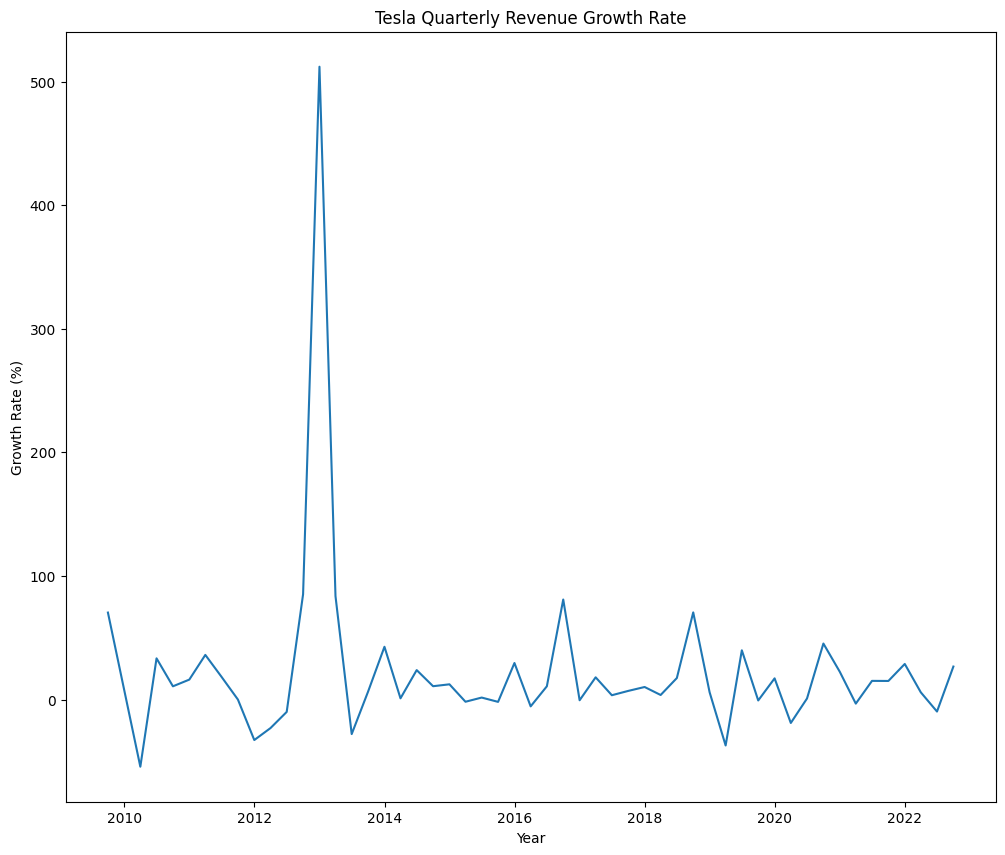

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
plt.plot(tesla_revenue['Date'], tesla_revenue['Growth_Rate_%'])
plt.title("Tesla Quarterly Revenue Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.show()

<span style="color:blue;font-family:Arial;font-weight:bold; font-size:15px;">ANALYSIS :</span>

<span style="color:black;font-family:Arial; font-size:15px;">
The table presents Tesla's quarterly revenue history and growth rates from 2010 to 2022, while the graph visualizes the quarter-over-quarter growth rate trends. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services. Revenue is the top line item on an income statement from which all costs and expenses are subtracted to arrive at net income.<br>
Tesla revenue for the quarter ending September 30, 2022 was \$21.454B, a 55.95% increase year-over-year, indicating strong growth.<br>
Tesla revenue for the twelve months ending September 30, 2022 was \$74.863B, a 59.8% increase year-over-year. This implies Tesla's massive expansion.<br>
Tesla annual revenue for 2021 was \$53.823B, a 70.67% increase from 2020.<br>
Tesla annual revenue for 2020 was \$31.536B, a 28.31% increase from 2019.<br>
Tesla annual revenue for 2019 was \$24.578B, a 14.52% increase from 2018.<br>
These figures demonstrate Tesla’s transition from an early-stage company with volatile growth to a rapidly expanding company. While earlier years (2010–2014) show larger fluctuations in growth rates, recent years reflect more sustained and consistent revenue expansion.
</span>

<span style="color:purple;font-family:Bahnschrift; font-size:24px; font-weight:bold;">
(3)Use yfinance to Extract Stock Data
</span>

<span style="color:black;font-family:Arial; font-size:15px;">
Using the Ticker function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is GameStop and its ticker symbol is GME.Using the ticker object and the function history extract stock information and save it in a dataframe named gme_data. Set the period parameter to "max" so we get information for the maximum amount of time.Reset the index using the reset_index(inplace=True) function on the gme_data DataFrame and display the first five rows of the gme_data dataframe using the head function. 
</span>

In [9]:
import yfinance as yf
GameStop=yf.Ticker("GME")
gme_data=GameStop.history(period="max")
gme_data.reset_index(inplace=True)
print(gme_data.head(5))

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691666  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716073  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658001  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615921  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


<span style="color:blue;font-family:Arial;font-weight:bold; font-size:15px;">ANALYSIS :</span>
<span style="color:black;font-family:Arial; font-size:15px;">The displayed data shows the initial portion of GameStop's historical stock data starting from February 2002.</span><br><span style="color:black;font-family:Arial; font-size:15px;">Open- The first price at which the stock was traded when the market opened that day.<br>Close- The last price at which the stock was traded when the market closed that day.<br>High- The highest price stock reached during that trading day.<br>Low- The lowest price stock reached during that trading day.<br>Volume- The number of shares traded during that day.<br>Dividends-Money that a company( i.e. GameStop) pays to its shareholders from its profits.<br>Stock splits- Occurs when a company increases the number of shares while reducing the price per share so that the total market value remains the same.<br>Averages of open, close, high, low are 1.6596848, 1.6638928, 1.6851018, 1.6226532 respectively. Since the average closing price is slightly higher than the average opening price, the stock tended to close slightly higher than it opened during the trading day on average in this short sample period. Large trading volumes imply significant investor interest in GameStop's stock. Dividends column is 0, indicates that GameStop does not distribute dividends and instead reinvests profits into growth and expansion. No stock split occurred during the duration.</span><br>

<span style="color:purple;font-family:Bahnschrift; font-size:24px; font-weight:bold;">
(4)Use Webscraping to Extract GME Revenue Data
</span>

<span style="color:black;font-family:Arial; font-size:15px;">
Use the requests library to download the webpage</span><span style="color:blue;font-family:Arial; font-size:15px;"> https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html</span><span style="color:black;font-family:Arial; font-size:15px;">Save the text of the response as a variable named html_data_2.Parse the html data using beautiful_soup using parser i.e html5lib or html.parser.Using BeautifulSoup or the read_html function extract the table with GameStop Revenue and store it into a dataframe named gme_revenue. The dataframe should have columns Date and Revenue. The comma and dollar sign is removed from the Revenue column.
</span>

In [10]:
import requests
import pandas
from bs4 import BeautifulSoup
url=" https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2=requests.get(url).text
soup=BeautifulSoup(html_data_2,'html.parser')
gme_revenue=pandas.DataFrame(columns=["Date","Revenue"])
table=soup.find_all('table')[1]
for row in table.tbody.find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    new_row=pandas.DataFrame([{"Date":date,"Revenue":revenue}])
    gme_revenue=pandas.concat([gme_revenue,new_row],ignore_index=True)
print(gme_revenue)

          Date Revenue
0   2020-04-30  $1,021
1   2020-01-31  $2,194
2   2019-10-31  $1,439
3   2019-07-31  $1,286
4   2019-04-30  $1,548
..         ...     ...
57  2006-01-31  $1,667
58  2005-10-31    $534
59  2005-07-31    $416
60  2005-04-30    $475
61  2005-01-31    $709

[62 rows x 2 columns]


<span style="color:black;font-family:Arial; font-size:15px;">Removing the comma and dollar sign from the Revenue column.</span>

In [11]:
gme_revenue['Revenue']=gme_revenue['Revenue'].str.replace(',|\\$',"",regex=True)
print(gme_revenue)

          Date Revenue
0   2020-04-30    1021
1   2020-01-31    2194
2   2019-10-31    1439
3   2019-07-31    1286
4   2019-04-30    1548
..         ...     ...
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709

[62 rows x 2 columns]


<span style="color:black;font-family:Arial; font-size:15px;">Removing null or empty strings in the Revenue column.</span>

In [13]:
gme_revenue.dropna(inplace=True)
gme_revenue =gme_revenue[gme_revenue['Revenue'] != ""]
print(gme_revenue)

          Date Revenue
0   2020-04-30    1021
1   2020-01-31    2194
2   2019-10-31    1439
3   2019-07-31    1286
4   2019-04-30    1548
..         ...     ...
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709

[62 rows x 2 columns]


<span style="color:black;font-family:Arial; font-size:15px;">Displaying the last 5 rows of the gme_revenue dataframe using the tail function.</span>

In [14]:
print(gme_revenue.tail(5))

          Date Revenue
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709


<span style="color:purple;font-family:Times New Roman;font-weight:bold; font-size:20px;">GameStop's Quarterly Revenue Growth Rate</span>

In [5]:
import requests
import pandas
from bs4 import BeautifulSoup
url=" https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2=requests.get(url).text
soup=BeautifulSoup(html_data_2,'html.parser')
gme_revenue=pandas.DataFrame(columns=["Date","Revenue"])
table=soup.find_all('table')[1]
for row in table.tbody.find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    new_row=pandas.DataFrame([{"Date":date,"Revenue":revenue}])
    gme_revenue=pandas.concat([gme_revenue,new_row],ignore_index=True)
gme_revenue['Revenue']=gme_revenue['Revenue'].str.replace(',|\\$',"",regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue =gme_revenue[gme_revenue['Revenue'] != ""]
gme_revenue['Date'] = pd.to_datetime(gme_revenue['Date'])

gme_revenue = gme_revenue.sort_values(by='Date')
gme_revenue['Revenue']=gme_revenue['Revenue'].astype(float)
gme_revenue['Growth_Rate_%'] = gme_revenue['Revenue'].pct_change() * 100
gme_revenue['Growth_Rate_%'] = gme_revenue['Growth_Rate_%'].round(2)
print(gme_revenue)

         Date  Revenue  Growth_Rate_%
61 2005-01-31    709.0            NaN
60 2005-04-30    475.0         -33.00
59 2005-07-31    416.0         -12.42
58 2005-10-31    534.0          28.37
57 2006-01-31   1667.0         212.17
..        ...      ...            ...
4  2019-04-30   1548.0         -49.46
3  2019-07-31   1286.0         -16.93
2  2019-10-31   1439.0          11.90
1  2020-01-31   2194.0          52.47
0  2020-04-30   1021.0         -53.46

[62 rows x 3 columns]


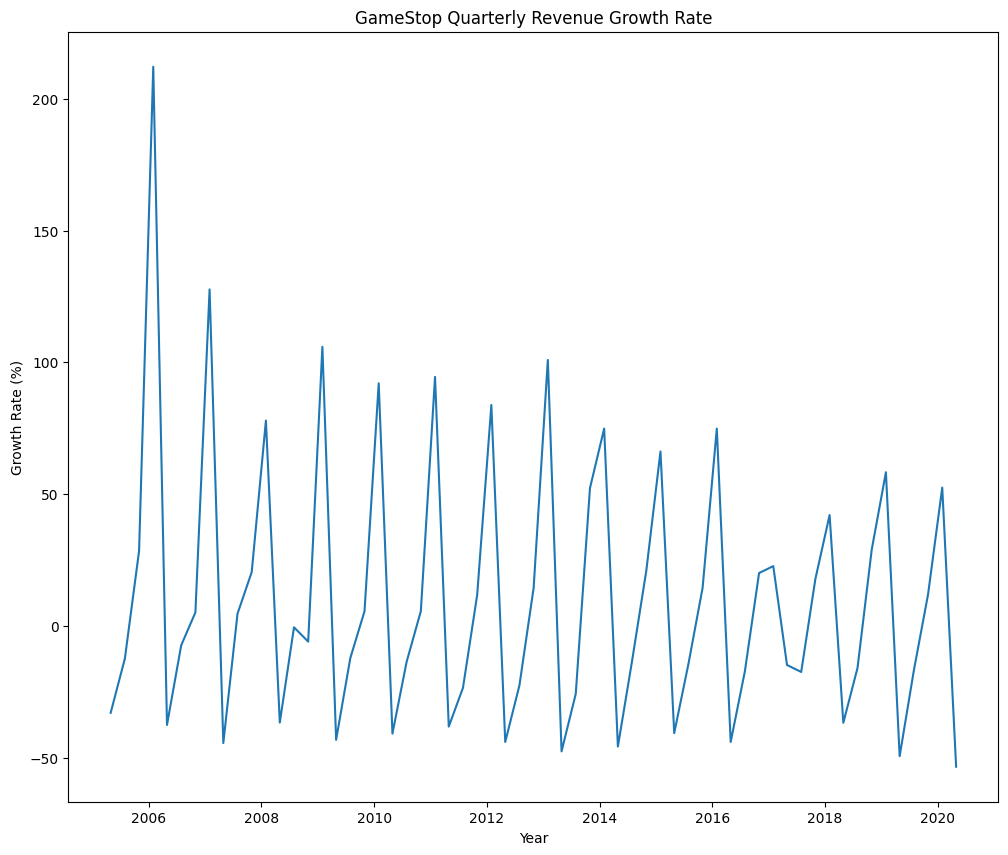

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
plt.plot(gme_revenue['Date'], gme_revenue['Growth_Rate_%'])
plt.title("GameStop Quarterly Revenue Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.show()

<span style="color:blue;font-family:Arial; font-size:15px; font-weight:bold;">ANALYSIS :</span>
<span style="color:black;font-family:Arial; font-size:15px;">The table presents GameStop's quarterly revenue history and growth rates from 2005 to 2020, while the graph visualizes the quarter-over-quarter growth rate trends.Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services. Revenue is the top line item on an income statement from which all costs and expenses are subtracted to arrive at net income.GameStop’s quarterly revenue growth rate shows significant fluctuations over time. Some quarters exhibit positive growth due to factors such as new console releases and increased gaming demand, while others show negative growth reflecting declining sales. Overall, the variability in growth rates suggests that GameStop’s revenue performance is inconsistent and influenced by changes in the gaming industry, particularly the shift from physical retail sales to digital game distribution.</span>

<span style="color:purple;font-family:Bahnschrift; font-size:24px; font-weight:bold;">
(5)Plot Tesla Stock Graph
</span>

<span style="color:black;font-family:Arial; font-size:15px;">Using the make_graph function to graph the Tesla Stock Data, and a title is also provided for the graph. The graph will only show data upto June 2021.</span>

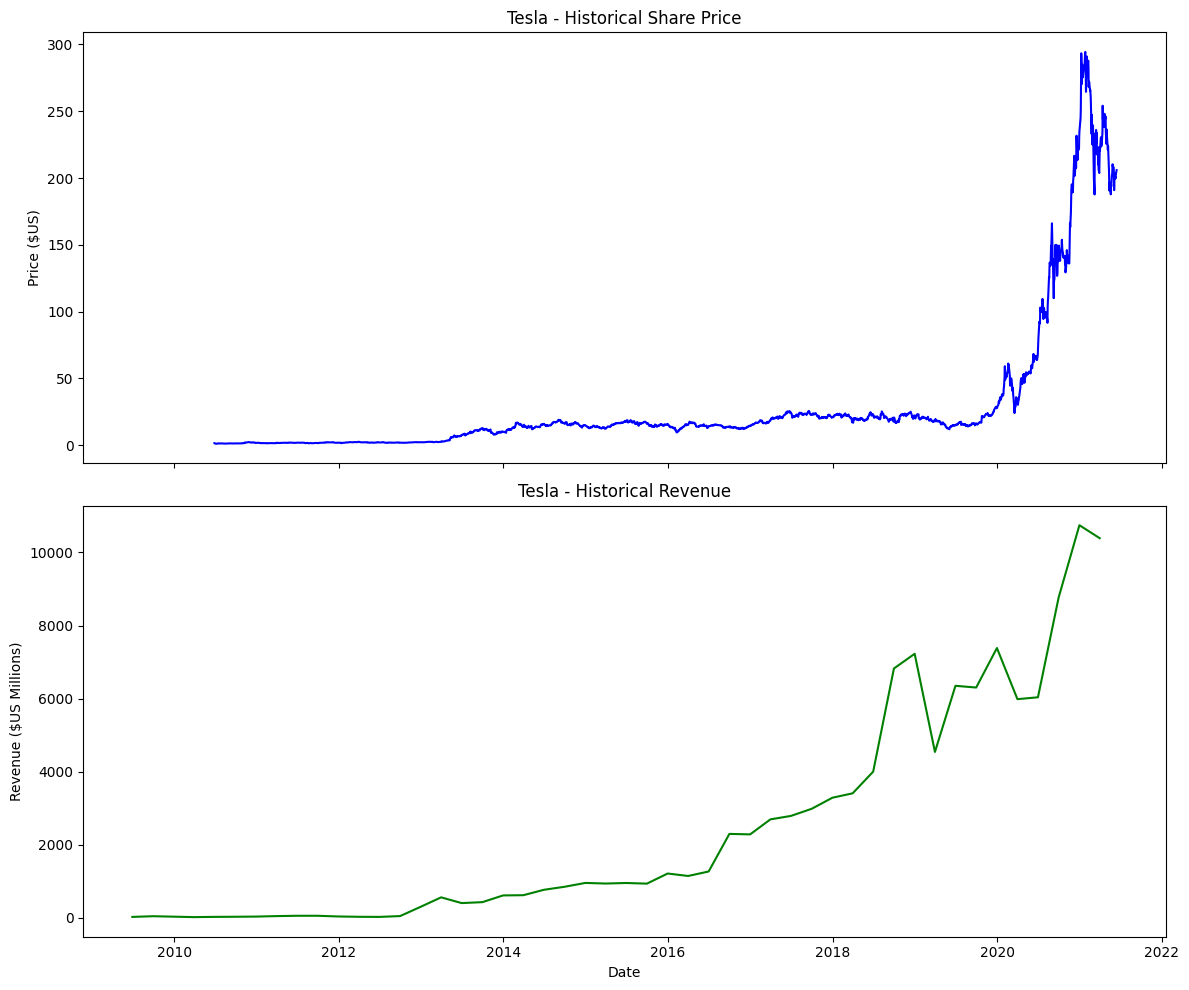

In [6]:
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import pandas as pd
import yfinance as yf
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")
    plt.tight_layout()
    plt.show()
tesla=yf.Ticker("TSLA")
tesla_data=tesla.history (period="max")
tesla_data.reset_index(inplace=True)
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data=requests.get(url).text
soup=BeautifulSoup(html_data,'html.parser')
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])
tables=soup.find_all('table')
table=tables[1]
for row in table.tbody.find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    new_row=pd.DataFrame([{"Date":date,"Revenue":revenue}])
    tesla_revenue=pd.concat([tesla_revenue,new_row],ignore_index=True) 
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\\$',"",regex=True)
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
make_graph(tesla_data,tesla_revenue,'Tesla')

<span style="color:blue;font-family:Arial; font-size:15px; font-weight:bold;">ANALYSIS :</span><br>
<span style="color:black;font-family:Arial;font-size:15px;">Share Price Graph:Tesla’s stock price rises substantially over time, indicating growing investor confidence in the company’s future. The graph also shows large fluctuations (sharp rises and falls) around 2021, which can occur due to factors such as changes in revenue, technological developments, competition, and broader economic conditions.<br>
Revenue Graph:Tesla’s revenue increases significantly over the years, indicating that the company is selling more vehicles and expanding its business operations. In later years, revenue grows more rapidly, reflecting increased adoption of electric vehicles, expansion of production facilities, and entry into new markets.<br>
As Tesla’s revenue increases, the share price also tends to rise. This suggests that investors respond positively to Tesla’s improving financial performance and growth potential.</span>

<span style="color:purple;font-family:Bahnschrift; font-size:24px; font-weight:bold;">
(6)Plot GameStop Stock Graph
</span>

<span style="color:black;font-family:Arial; font-size:15px;">Using the make_graph function to graph the GameStop Stock Data, and a title is also provided for the graph. The graph will only show data upto June 2021.</span>

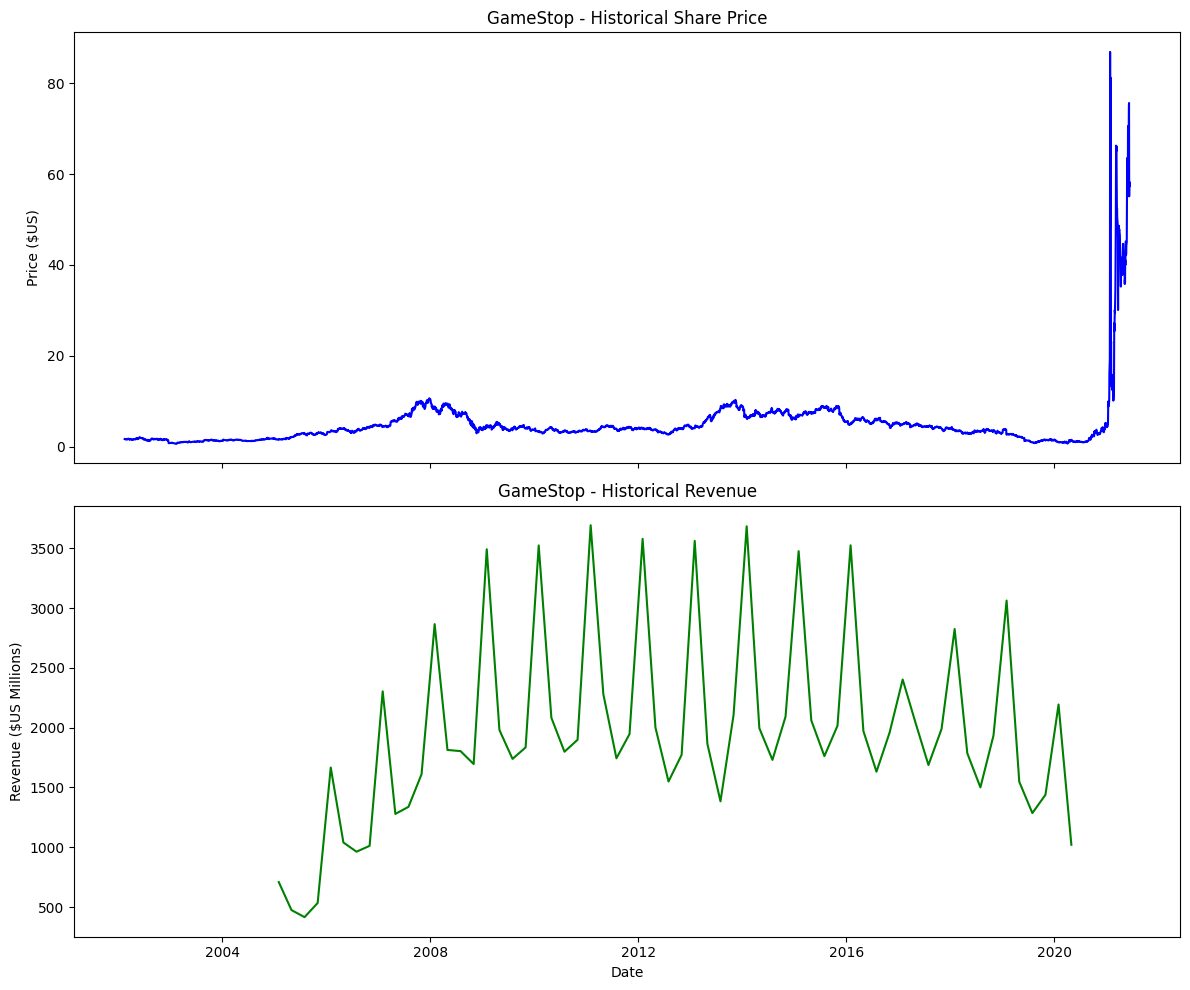

In [2]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import yfinance as yf
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")
    plt.tight_layout()
    plt.show()
GameStop=yf.Ticker("GME")
gme_data=GameStop.history(period="max")
gme_data.reset_index(inplace=True)
url=" https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2=requests.get(url).text
soup=BeautifulSoup(html_data_2,'html.parser')
gme_revenue=pandas.DataFrame(columns=["Date","Revenue"])
table=soup.find_all('table')[1]
for row in table.tbody.find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    new_row=pandas.DataFrame([{"Date":date,"Revenue":revenue}])
    gme_revenue=pandas.concat([gme_revenue,new_row],ignore_index=True)
gme_revenue['Revenue']=gme_revenue['Revenue'].str.replace(',|\\$',"",regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue =gme_revenue[gme_revenue['Revenue'] != ""]
make_graph(gme_data, gme_revenue, 'GameStop')

<span style="color:blue;font-family:Arial; font-size:15px; font-weight:bold;">ANALYSIS :</span><br>
<span style="color:black;font-family:Arial;font-size:15px;">Share Price Graph: GameStop’s share price shows very large spikes and drops, especially around 2021.The sharp rise in early 2021 was largely driven by retail investors, rather than improvements in company fundamentals.After the peak, the price dropped significantly but remained more volatile than before 2021.<br>
Revenue Graph: GameStop’s revenue generally declines over time as physical video game sales decrease. The fall reflects the gaming industry moving toward digital downloads and online platforms, reducing the need for physical retail stores.<br>
GameStop’s share price does not closely follow its revenue trend.The share price increased despite declining revenues, showing that the stock was influenced more by investor interest rather than fundamental business growth and financial performance.</span>